# Deep Learning for Computer Vision:  HW 2


## Computer Science: COMS W 4995 006


## Due: October 19, 2021

#### Problem

You are given the noisy XOR data generated for you below. Your task is to implement a multi-layer perceptron binary classifier with one hidden layer. For the activiation function of the hidden units use ReLu. For the loss function use a softplus on a linear output layer as we did in class.

a) Implement each layer of the network as a separate function with both forward propagation and backpropagation. 

b) Train the network using stochastic gradient descent with mini-batches.  

c) Show the decision regions of the trained classifier by densely generating points in the plane and color coding these points with the binary labels. 

d) Repeat (b) and (c) varying the number of hidden units: 3, 16, 512. Discuss how the number of hidden units effects the solution.

e) Try choosing your own loss function (**without asking me or the TAs what you should choose**), repeating (d).

f) Now try with three inputs, generating your own training and testing data. (For this XOR the output should be a 1 if and only if exactly one of the inputs is 1. But make the training data noisy as before.) Use softplus loss. Do not try to show the decision regions, instead generate a test set in the same manner as the training set, classify the samples, and compute the classification accuracy.

g) Using your data from HW1 or any new data you curate, train your MLP using your training set (80%). Compute the error rate on your test set (20%). It's up to you how many hidden units to use. 

If you are struggling to get the network to converge, experiment with different learning rates.

Grading: a-d = 65%, e=10%, f=5%, g=20%. 

#### NOTE:  Do not to use keras, tensorflow, pytorch, sklearn, etc. to do this.  You must build the machine learning components from scratch.



Let's start by importing some libraries.

#### Using the same data as HW1: https://drive.google.com/drive/folders/1F5GstW_-G5gMGsYNLLvDU7XMCewrZI0A?usp=sharing

In [1]:
# !pip install rasterio
# !pip install matplotlib
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt

Let's make up some noisy XOR data.

In [2]:
data = pd.DataFrame(np.zeros((5000, 3)), columns=['x1', 'x2', 'y'])

# Let's make up some noisy XOR data to use to build our binary classifier
for i in range(len(data.index)):
    x1 = 1.0 * random.randint(0,1)
    x2 = 1.0 * random.randint(0,1)
    y = 1.0 * np.logical_xor(x1==1,x2==1)
    x1 = x1 + 0.15 * np.random.normal()
    x2 = x2 + 0.15 * np.random.normal()
    data.iloc[i,0] = x1
    data.iloc[i,1] = x2
    data.iloc[i,2] = y
        
data.head()

,x1,x2,y
0,1.250314,0.907457,0.0
1,0.001465,1.024525,1.0
2,0.986921,1.033565,0.0
3,-0.099939,-0.311135,0.0
4,0.752004,0.846129,0.0


Let's message this data into a numpy format.

In [3]:
# set X (training data) and y (target variable)
cols = data.shape[1]
X = data.iloc[:,0:cols-1]
y = data.iloc[:,cols-1:cols]

# The cost function is expecting numpy matrices so we need to convert X and y before we can use them.  
X = np.matrix(X.values)
y = np.matrix(y.values)

Let's make a sloppy plotting function for our binary data.

In [4]:
# Sloppy function for plotting our data
def plot_data(X, y_prob):
    
    fig, ax = plt.subplots(figsize=(12,8))
    ax.margins(0.05) # Optional, just adds 5% padding to the autoscaling

    y_predict = y_prob > 0.5
    indices_0 = [k for k in range(0, X.shape[0]) if not y_predict[k]]
    indices_1 = [k for k in range(0, X.shape[0]) if y_predict[k]]

    ax.plot(X[indices_0, 0], X[indices_0,1], marker='o', linestyle='', ms=5, label='0')
    ax.plot(X[indices_1, 0], X[indices_1,1], marker='o', linestyle='', ms=5, label='1')

    ax.legend()
    ax.legend(loc=2)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_title('Noisy XOR')
    plt.show()

Now let's plot it.

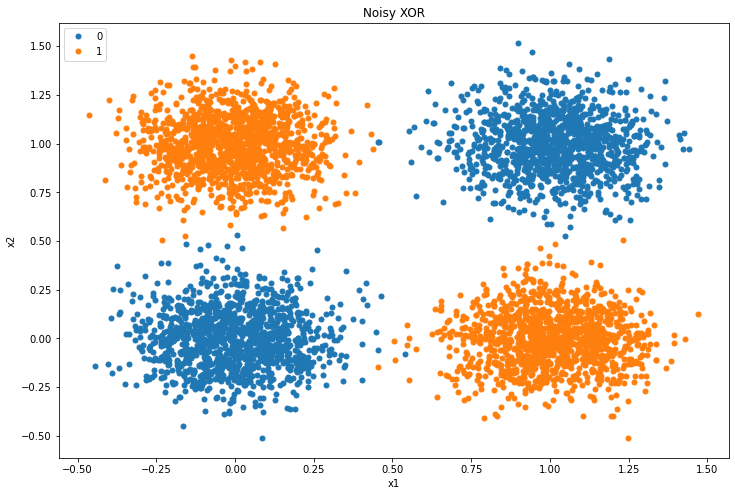

In [5]:
plot_data(X, y)

Now let's create functions for forward and backward prop through the layers and we are off...

# a-d

In [6]:
def forward_prop(x,y,W,c,w,b):
    #hidden layer
    h = np.maximum(np.dot(np.transpose(W), x) + c, 0)
    #output layer
    z = np.dot(np.transpose(w), h) + b
    #loss layer
    L = np.log(1 + np.exp((1-2*y)*z))
    return h,z,L

def backward_prop(x,y,h,z,W,c,w,b):
    #loss layer
    dL_dz = 1 / (1 + np.exp((1-2*y)*-z)) * (1 - 2*y)
    #output layer
    dL_db = dL_dz 
    dL_dw = np.multiply(dL_dz, h)
    dL_dh = np.multiply(dL_dz, w)
    #hidden layer
    a = np.dot(np.transpose(W), x) + c 
    f = 1.0 * (a > 0) #slope is 1 for a>0
    dL_dc = np.multiply(f, dL_dh)
    dL_dW = np.dot(x, np.transpose(np.multiply(f, dL_dh)))
    return dL_dW, dL_dc, dL_dw, dL_db

In [7]:
def gradient_decent(X, y, W, c, w, b, iterations, batch_size):
    cost = np.zeros(iterations)
    N = X.shape[0]

    for i in range(1, iterations):
        W_new, c_new, w_new, b_new = [], [], [], []
        
        for j in range(1, batch_size+1):
            k = random.randint(0, N-1)
            
            h, z, cost[i] = forward_prop(np.transpose(X[k,:]), y[k], W, c, w, b)
            dL_dW, dL_dc, dL_dw, dL_db = backward_prop(np.transpose(X[k,:]), y[k], h, z, W, c, w, b)
            
            W_new.append(dL_dW)
            c_new.append(dL_dc)
            w_new.append(dL_dw)
            b_new.append(dL_db)
            
        del_W = np.mean(np.array(W_new), dtype = np.float, axis = 0)
        del_c = np.mean(np.array(c_new), dtype = np.float, axis = 0)
        del_w = np.mean(np.array(w_new), dtype = np.float, axis = 0)
        del_b = np.mean(np.array(b_new), dtype = np.float, axis = 0)

        W = W - 0.1 * del_W
        c = c - 0.1 * del_c 
        w = w - 0.1 * del_w
        b = b - 0.1 * del_b

    return W, c, w, b, cost 

In [8]:
def MLP(hidden_units, iterations, batch_size):

    W = np.random.random((2,hidden_units)) - 0.5 
    c = np.random.random((hidden_units,1)) * 0.1
    w = np.random.random((hidden_units,1)) - 0.5 
    b = np.random.random() * 0.1

    W, c, w, b, cost = gradient_decent(X, y, W, c, w, b, iterations, batch_size)

    y_predict = np.zeros(X.shape[0])
    loss = np.zeros(X.shape[0])
    
    for i in range(X.shape[0]):
        h, z, loss[i] = forward_prop(np.transpose(X[i,:]), y[i], W, c, w, b)
        y_predict[i] = 1/ (1 + np.exp(-z))

    print('Loss per sample = ', np.mean(loss))

    return W, c, w, b

In [9]:
def test(XX, yy, W, c, w, b):
    for i in range(0, XX.shape[0]):
        h, z, cost = forward_prop(np.transpose(XX[i,:]), yy[i], W, c, w, b)
        yy_prob[i] = 1/ (1 + np.exp(-z))
        
    plot_data(XX,yy_prob)

Loss per sample =  0.18396864918487846


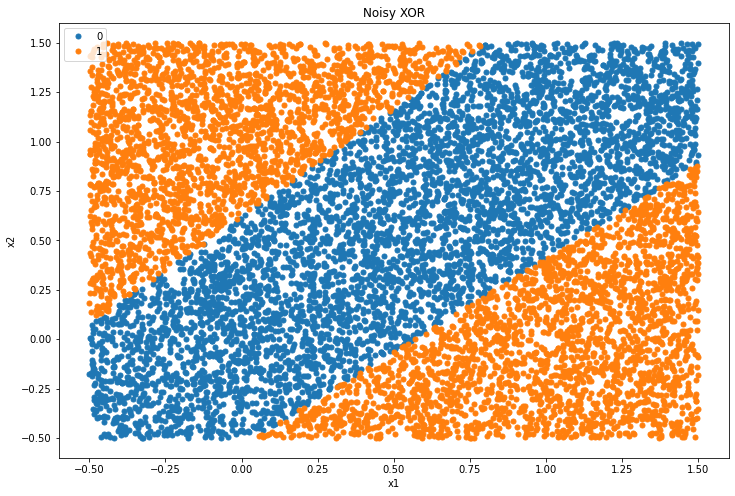

In [11]:
XX = 2 * np.matrix(np.random.random((10000,2))) - 0.5
yy = np.zeros(100000)
yy_prob = np.zeros(100000)

W, c, w, b = MLP(2, 1000, 16)
test(XX, yy, W, c, w, b)

# 3 hidden units

Loss per sample =  0.1087189629407445


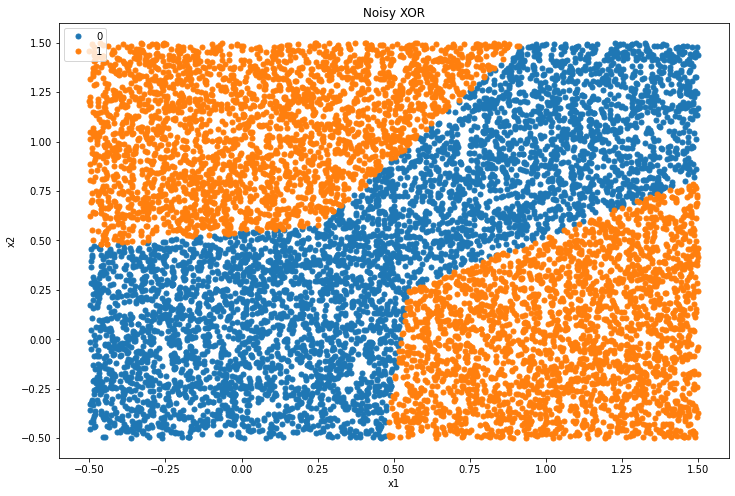

In [12]:
XX = 2 * np.matrix(np.random.random((10000,2))) - 0.5
yy = np.zeros(100000)
yy_prob = np.zeros(100000)

W, c, w, b = MLP(3, 1000, 16)
test(XX, yy, W, c, w, b)

# 16 hidden units

Loss per sample =  0.038453913651751714


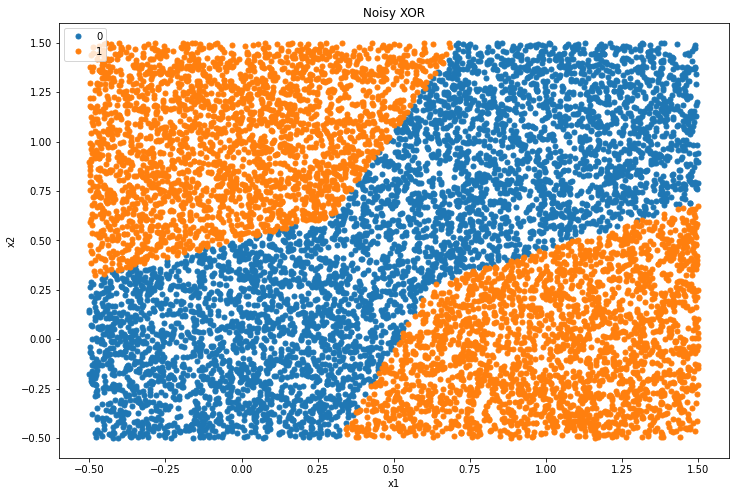

In [13]:
XX = 2 * np.matrix(np.random.random((10000,2))) - 0.5
yy = np.zeros(100000)
yy_prob = np.zeros(100000)

W, c, w, b = MLP(16, 1000, 16)
test(XX, yy, W, c, w, b)

# 512 hidden units

Loss per sample =  0.019687909512699272


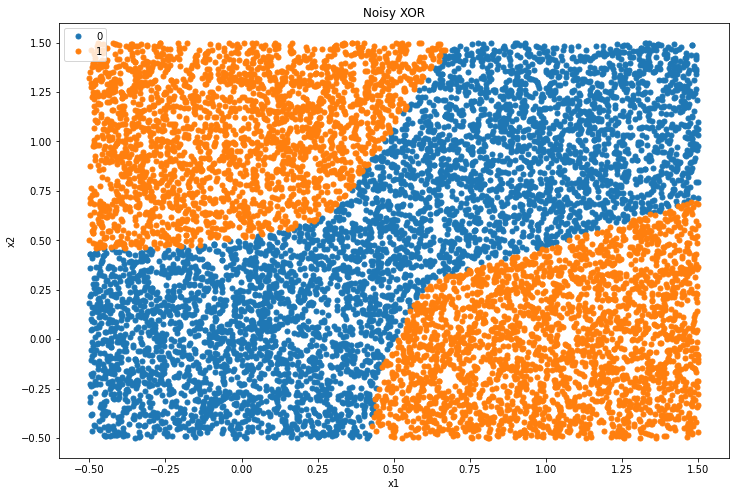

In [14]:
XX = 2 * np.matrix(np.random.random((10000,2))) - 0.5
yy = np.zeros(100000)
yy_prob = np.zeros(100000)

W, c, w, b = MLP(512, 1000, 16)
test(XX, yy, W, c, w, b)

### Increasing the number of hidden units makes it easier to converge to XOR fit as the loss goes down

# e
## Let's use MSE as the loss function

In [15]:
def forward_prop(x,y,W,c,w,b):
    #hidden layer
    h = np.maximum(np.dot(np.transpose(W), x) + c, 0.01* np.dot(np.transpose(W), x))
    #output layer
    z = 1 / (1 + np.exp(-(np.dot(np.transpose(w), h) + b)))
    #loss layer
    L = (z-y)**2
    return h,z,L

def backward_prop(x,y,h,z,W,c,w,b):
    #loss layer
    dL_dz = (2*(z-y))*(z*(1-z))
    #output layer
    dL_db = dL_dz 
    dL_dw = np.multiply(dL_dz, h)
    dL_dh = np.multiply(dL_dz, w)
    #hidden layer
    a = np.dot(np.transpose(W), x) + c 
    f = 1 * (a > 0.0) + 0.01 * (a< 0.0)
    dL_dc = np.multiply(f, dL_dh)
    dL_dW = np.dot(x, np.transpose(np.multiply(f, dL_dh)))
    return dL_dW, dL_dc, dL_dw, dL_db

In [16]:
def gradient_decent(X, y, W, c, w, b, iterations, batch_size):
    cost = np.zeros(iterations)
    N = X.shape[0]

    for i in range(1, iterations):
        eta = 1 * np.exp(-i/100.0)
        
        for j in range(1, batch_size+1):
            k = random.randint(0, N-1)
            
            h, z, cost[i] = forward_prop(np.transpose(X[k,:]), y[k], W, c, w, b)
            dL_dW, dL_dc, dL_dw, dL_db = backward_prop(np.transpose(X[k,:]), y[k], h, z, W, c, w, b)
            
            if i == 1: 
                del_W = dL_dW 
                del_c = dL_dc 
                del_w = dL_dw 
                del_b = dL_db 
            else: 
                del_W = del_W + dL_dW 
                del_c = del_c + dL_dc 
                del_w = del_w + dL_dw 
                del_b = del_b + dL_db

        W = W - (1 / batch_size) * eta * del_W
        c = c - (1/ batch_size) * eta * del_c 
        w = w - (1/ batch_size) * eta * del_w
        b = b - (1/ batch_size) * eta * del_b

    return W, c, w, b, cost 

In [17]:
def MLP(hidden_units, iterations, batch_size):

    W = np.random.random((2,hidden_units)) - 0.5 
    c = np.random.random((hidden_units,1)) * 0.1
    w = np.random.random((hidden_units,1)) - 0.5 
    b = np.random.random() * 0.1

    W, c, w, b, cost = gradient_decent(X, y, W, c, w, b, iterations, batch_size)

    y_predict = np.zeros(X.shape[0])
    loss = np.zeros(X.shape[0])
    
    for i in range(X.shape[0]):
        h, z, loss[i] = forward_prop(np.transpose(X[i,:]), y[i], W, c, w, b)
        y_predict[i] = z

    print('Loss per sample = ', np.mean(loss))

    return W, c, w, b

In [18]:
def test(XX, yy, W, c, w, b):
    for i in range(0, XX.shape[0]):
        h, z, cost = forward_prop(np.transpose(XX[i,:]), yy[i], W, c, w, b)
        yy_prob[i] = 1/ (1 + np.exp(-z))
        
    plot_data(XX,yy_prob)

# 2 hidden units

Loss per sample =  0.01783266225743388


C:\Users\hssid\anaconda3\envs\gis3.6\lib\site-packages\ipykernel_launcher.py:5: RuntimeWarning: overflow encountered in exp
  """


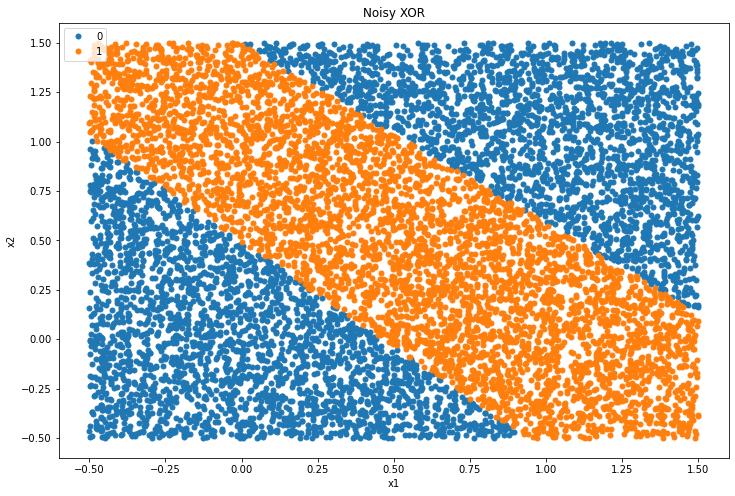

In [19]:
XX = 2 * np.matrix(np.random.random((10000,2))) - 0.5
yy = np.zeros(100000)
yy_prob = np.zeros(100000)

W, c, w, b = MLP(2, 1000, 16)
test(XX, yy, W, c, w, b)

# 3 hidden units

Loss per sample =  0.040926585310064


C:\Users\hssid\anaconda3\envs\gis3.6\lib\site-packages\ipykernel_launcher.py:5: RuntimeWarning: overflow encountered in exp
  """


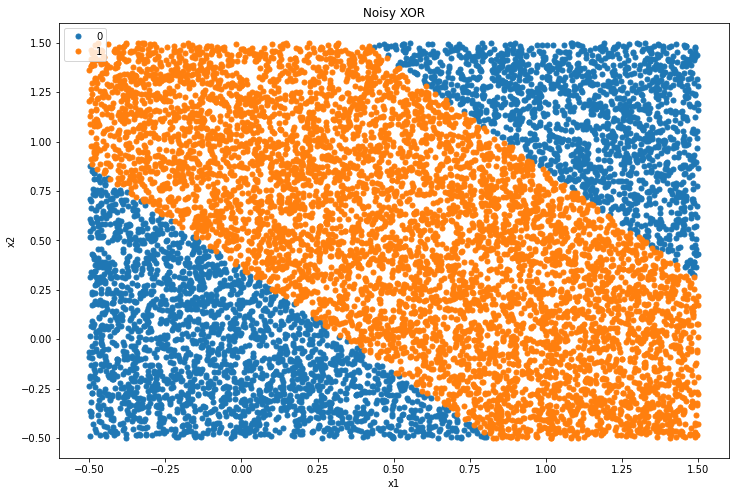

In [25]:
XX = 2 * np.matrix(np.random.random((10000,2))) - 0.5
yy = np.zeros(100000)
yy_prob = np.zeros(100000)

W, c, w, b = MLP(3, 1000, 16)
test(XX, yy, W, c, w, b)

# 16 hidden units

Loss per sample =  0.009171853359527178


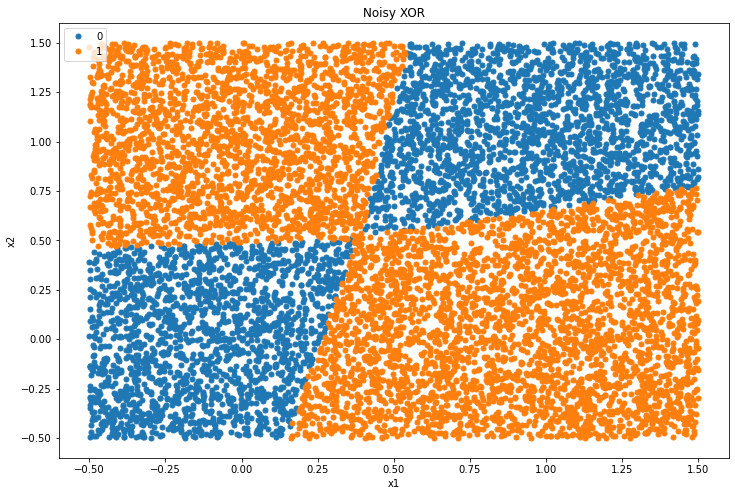

In [26]:
XX = 2 * np.matrix(np.random.random((10000,2))) - 0.5
yy = np.zeros(100000)
yy_prob = np.zeros(100000)

W, c, w, b = MLP(16, 1000, 16)
test(XX, yy, W, c, w, b)

# 512 Hidden units

C:\Users\hssid\anaconda3\envs\gis3.6\lib\site-packages\ipykernel_launcher.py:5: RuntimeWarning: overflow encountered in exp
  """


Loss per sample =  0.014122174563545252


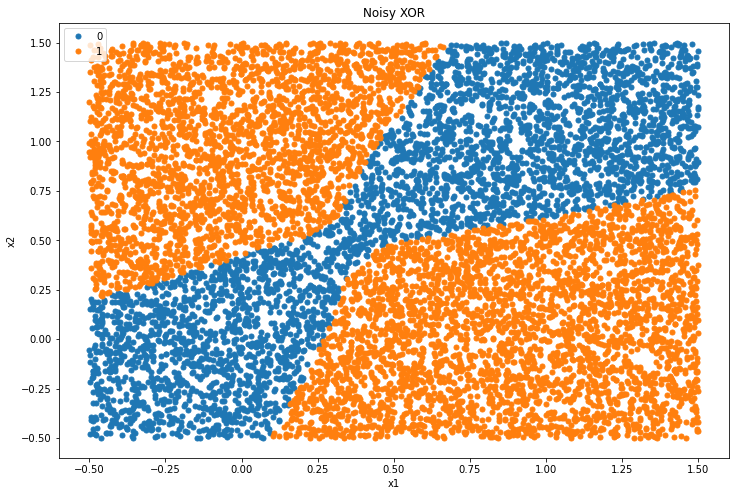

In [32]:
XX = 2 * np.matrix(np.random.random((10000,2))) - 0.5
yy = np.zeros(100000)
yy_prob = np.zeros(100000)

W, c, w, b = MLP(512, 1000, 16)
test(XX, yy, W, c, w, b)

# f
## 3 inputs

In [33]:
data = pd.DataFrame(np.zeros((10000, 4)), columns=['x1', 'x2', 'x3', 'y'])

# Let's make up some noisy XOR data to use to build our binary classifier
for i in range(len(data.index)):
    x1 = 1.0 * random.randint(0,1)
    x2 = 1.0 * random.randint(0,1)
    x3 = 1.0 * random.randint(0,1)
    y = 1.0 * np.logical_xor(x1==1,np.logical_xor(x2==1, x3==1))
    x1 = x1 + 0.15 * np.random.normal()
    x2 = x2 + 0.15 * np.random.normal()
    x3 = x3 + 0.15 * np.random.normal()
    data.iloc[i,0] = x1
    data.iloc[i,1] = x2
    data.iloc[i,2] = x3
    data.iloc[i,3] = y
        
data.head()

,x1,x2,x3,y
0,-0.017972,1.082500,1.032444,0.0
1,1.068829,0.872830,1.082288,1.0
2,-0.043361,0.106868,1.103655,1.0
3,0.902255,0.012963,1.139312,0.0
4,1.028155,-0.155749,-0.076452,1.0


In [34]:
train = data[0:8000]
test = data[8000:10000]
print(train.shape, test.shape)

(8000, 4) (2000, 4)


In [35]:
# set X (training data) and y (target variable)
cols = train.shape[1]
X_train = train.iloc[:,0:cols-1]
y_train = train.iloc[:,cols-1:cols]
cols = test.shape[1]
X_test = test.iloc[:, 0:cols-1]
y_test = test.iloc[:, cols-1:cols]
# The cost function is expecting numpy matrices so we need to convert X and y before we can use them.  
X_train = np.matrix(X_train.values)
y_train = np.matrix(y_train.values)
X_test = np.matrix(X_test.values)
y_test = np.matrix(y_test.values)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(8000, 3) (8000, 1) (2000, 3) (2000, 1)


In [36]:
def forward_prop(x,y,W,c,w,b):
    #hidden layer
    h = np.maximum(np.dot(np.transpose(W), x) + c, 0)
    #output layer
    z = np.dot(np.transpose(w), h) + b
    #loss layer
    L = np.log(1 + np.exp((1-2*y)*z))
    return h,z,L

def backward_prop(x,y,h,z,W,c,w,b):
    #loss layer
    dL_dz = 1 / (1 + np.exp((1-2*y)*-z)) * (1 - 2*y)
    #output layer
    dL_db = dL_dz 
    dL_dw = np.multiply(dL_dz, h)
    dL_dh = np.multiply(dL_dz, w)
    #hidden layer
    a = np.dot(np.transpose(W), x) + c 
    f = 1.0 * (a > 0) #slope is 1 for a>0
    dL_dc = np.multiply(f, dL_dh)
    dL_dW = np.dot(x, np.transpose(np.multiply(f, dL_dh)))
    return dL_dW, dL_dc, dL_dw, dL_db

In [37]:
def gradient_decent(X, y, W, c, w, b, iterations, batch_size):
    cost = np.zeros(iterations)
    N = X.shape[0]

    for i in range(1, iterations):
        W_new, c_new, w_new, b_new = [], [], [], []
        
        for j in range(1, batch_size+1):
            k = random.randint(0, N-1)
            
            h, z, cost[i] = forward_prop(np.transpose(X[k,:]), y[k], W, c, w, b)
            dL_dW, dL_dc, dL_dw, dL_db = backward_prop(np.transpose(X[k,:]), y[k], h, z, W, c, w, b)
            
            W_new.append(dL_dW)
            c_new.append(dL_dc)
            w_new.append(dL_dw)
            b_new.append(dL_db)
            
        del_W = np.mean(np.array(W_new), dtype = np.float, axis = 0)
        del_c = np.mean(np.array(c_new), dtype = np.float, axis = 0)
        del_w = np.mean(np.array(w_new), dtype = np.float, axis = 0)
        del_b = np.mean(np.array(b_new), dtype = np.float, axis = 0)

        W = W - 0.1 * del_W
        c = c - 0.1 * del_c 
        w = w - 0.1 * del_w
        b = b - 0.1 * del_b

    return W, c, w, b, cost 

In [38]:
def MLP(hidden_units, iterations, batch_size):

    W = np.random.random((3,hidden_units)) - 0.5 
    c = np.random.random((hidden_units,1)) * 0.1
    w = np.random.random((hidden_units,1)) - 0.5 
    b = np.random.random() * 0.1

    W, c, w, b, cost = gradient_decent(X_train, y_train, W, c, w, b, iterations, batch_size)

    y_predict = np.zeros(X_train.shape[0])
    loss = np.zeros(X_train.shape[0])
    
    for i in range(X_train.shape[0]):
        h, z, loss[i] = forward_prop(np.transpose(X_train[i,:]), y_train[i], W, c, w, b)
        y_predict[i] = 1/ (1 + np.exp(-z))

    print('Loss per sample = ', np.mean(loss))

    return W, c, w, b

In [39]:
def test(X, y, W, c, w, b):
    y_predict = np.zeros(X.shape[0])
    loss = np.zeros(X.shape[0])
    correct_pred=0
    
    for i in range(X.shape[0]):
        h, z, loss[i] = forward_prop(np.transpose(X[i,:]), y[i], W, c, w, b)
        temp = 1/ (1 + np.exp(-z))
        if temp>0.5:
            prediction = 1
        else:
            prediction = 0
        if prediction == int(y[i]):
            correct_pred+=1
    
    print('Accuracy = ', correct_pred/X.shape[0])

In [40]:
W, c, w, b = MLP(512, 1000, 16)
test(X_test, y_test, W, c, w, b)

Loss per sample =  0.054715848571235855
Accuracy =  0.996


# g
## Training on remote sensing data from HW1

In [41]:
import rasterio
from rasterio.plot import show
from rasterio.merge import merge
from matplotlib import pyplot
import math
import numpy as np
from rasterio.plot import show_hist

### Training Set

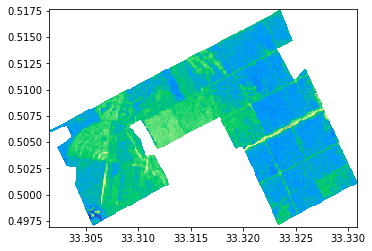

In [42]:
src = rasterio.open("C:/Users/hssid/Desktop/HW1/veg_training1.tif")
show(src, cmap='terrain')
img = src.read()[1]
meta = src.meta
red = img[np.where(img != meta['nodata'])]
img = src.read()[2]
green = img[np.where(img != meta['nodata'])]

stack=np.dstack((red,green))
stack = stack[0,:,:]

veg_training = pd.DataFrame(stack, columns = ['red','green'])
veg_training['veg'] = 1
# veg_training.head()

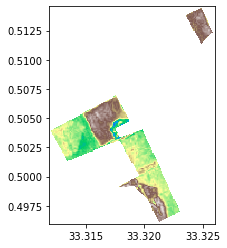

In [43]:
src = rasterio.open("C:/Users/hssid/Desktop/HW1/non_veg_training.tif")
show(src, cmap='terrain')
img = src.read()[1]
red = img[np.where(img != meta['nodata'])]
img = src.read()[2]
green = img[np.where(img != meta['nodata'])]

stack=np.dstack((red,green))
stack = stack[0,:,:]

non_veg_training = pd.DataFrame(stack, columns = ['red','green'])
non_veg_training['veg'] = 0
# non_veg_training.head()

In [44]:
train = pd.concat([veg_training, non_veg_training], ignore_index = True)
train.head(5)
train.head(-5)

,red,green,veg
0,2646,634,1
1,2616,627,1
2,2583,589,1
3,2609,560,1
4,2568,551,1
...,...,...,...
40126,2307,1466,0
40127,2396,1441,0
40128,2212,1286,0
40129,2139,1355,0


### Validation Set

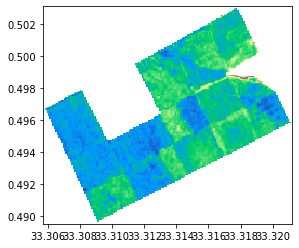

In [45]:
src = rasterio.open("C:/Users/hssid/Desktop/HW1/veg_test.tif")
show(src, cmap='terrain')

img = src.read()[1]
red = img[np.where(img != meta['nodata'])]
img = src.read()[2]
green = img[np.where(img != meta['nodata'])]

stack=np.dstack((red,green))
stack = stack[0,:,:]

veg_test = pd.DataFrame(stack, columns = ['red','green'])
veg_test['veg'] = 1

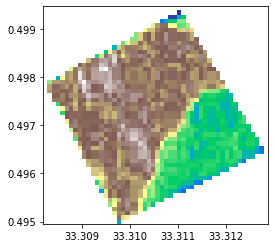

In [46]:
src = rasterio.open("C:/Users/hssid/Desktop/HW1/non_veg_test.tif")
show(src, cmap='terrain')

img = src.read()[1]
red = img[np.where(img != meta['nodata'])]
img = src.read()[2]
green = img[np.where(img != meta['nodata'])]

stack=np.dstack((red,green))
stack = stack[0,:,:]

non_veg_test = pd.DataFrame(stack, columns = ['red','green'])
non_veg_test['veg'] = 0

In [47]:
test = pd.concat([veg_test, non_veg_test], ignore_index = True)
test.head(5)
test.head(-5)

,red,green,veg
0,1983,826,1
1,2085,790,1
2,2359,717,1
3,2471,685,1
4,2332,731,1
...,...,...,...
12649,2152,1108,0
12650,2034,1249,0
12651,2035,1253,0
12652,2048,1304,0


In [48]:
# set X (training data) and y (target variable)
cols = train.shape[1]
X = train.iloc[:,0:cols-1]
y = train.iloc[:,cols-1:cols]

# set X (training data) and y (target variable)
cols = test.shape[1]
XX = test.iloc[:,0:cols-1]
yy = test.iloc[:,cols-1:cols]

# The cost function is expecting numpy matrices so we need to convert X and y before we can use them.  
X = np.matrix(X.values)
y = np.matrix(y.values)
XX = np.matrix(XX.values)
yy = np.matrix(yy.values)
print(X.shape, y.shape, XX.shape, yy.shape)

(40136, 2) (40136, 1) (12659, 2) (12659, 1)


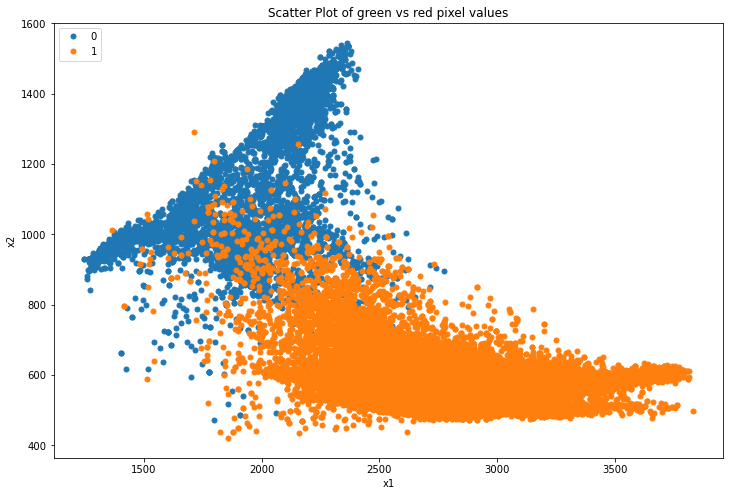

In [49]:
# Sloppy function for plotting our data
def plot_data(X, y_prob):
    
    fig, ax = plt.subplots(figsize=(12,8))
    ax.margins(0.05) # Optional, just adds 5% padding to the autoscaling

    y_predict = y_prob > 0.5
    indices_0 = [k for k in range(0, X.shape[0]) if not y_predict[k]]
    indices_1 = [k for k in range(0, X.shape[0]) if y_predict[k]]

    ax.plot(X[indices_0, 0], X[indices_0,1], marker='o', linestyle='', ms=5, label='0')
    ax.plot(X[indices_1, 0], X[indices_1,1], marker='o', linestyle='', ms=5, label='1')

    ax.legend()
    ax.legend(loc=2)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_title('Scatter Plot of green vs red pixel values')
    plt.show()
plot_data(X, y)

In [75]:
def forward_prop(x,y,W,c,w,b):
    #hidden layer
    h = np.maximum(np.dot(np.transpose(W), x) + c, 0)
    #output layer
    z = np.dot(np.transpose(w), h) + b
    #loss layer
    L = np.log(1 + np.exp((1-2*y)*z))
    return h,z,L

def backward_prop(x,y,h,z,W,c,w,b):
    #loss layer
    dL_dz = 1 / (1 + np.exp((1-2*y)*-z)) * (1 - 2*y)
    #output layer
    dL_db = dL_dz 
    dL_dw = np.multiply(dL_dz, h)
    dL_dh = np.multiply(dL_dz, w)
    #hidden layer
    a = np.dot(np.transpose(W), x) + c 
    f = 1.0 * (a > 0) #slope is 1 for a>0
    dL_dc = np.multiply(f, dL_dh)
    dL_dW = np.dot(x, np.transpose(np.multiply(f, dL_dh)))
    return dL_dW, dL_dc, dL_dw, dL_db

def gradient_decent(X, y, W, c, w, b, iterations, batch_size, lr):
    cost = np.zeros(iterations)
    N = X.shape[0]

    for i in range(1, iterations):
        W_new, c_new, w_new, b_new = [], [], [], []
        
        for j in range(1, batch_size+1):
            k = random.randint(0, N-1)
            
            h, z, cost[i] = forward_prop(np.transpose(X[k,:]), y[k], W, c, w, b)
            dL_dW, dL_dc, dL_dw, dL_db = backward_prop(np.transpose(X[k,:]), y[k], h, z, W, c, w, b)
            
            W_new.append(dL_dW)
            c_new.append(dL_dc)
            w_new.append(dL_dw)
            b_new.append(dL_db)
            
        del_W = np.mean(np.array(W_new), dtype = np.float64, axis = 0)
        del_c = np.mean(np.array(c_new), dtype = np.float64, axis = 0)
        del_w = np.mean(np.array(w_new), dtype = np.float64, axis = 0)
        del_b = np.mean(np.array(b_new), dtype = np.float64, axis = 0)

        W = W - lr * del_W
        c = c - lr * del_c 
        w = w - lr * del_w
        b = b - lr * del_b

    return W, c, w, b, cost 

def MLP(hidden_units, iterations, batch_size, learning_rate):

    W = np.random.random((2,hidden_units)) - 0.5 
    c = np.random.random((hidden_units,1)) * 0.1
    w = np.random.random((hidden_units,1)) - 0.5 
    b = np.random.random() * 0.1

    W, c, w, b, cost = gradient_decent(X, y, W, c, w, b, iterations, batch_size, learning_rate)

    y_predict = np.zeros(X.shape[0])
    loss = np.zeros(X.shape[0])
    
    for i in range(X.shape[0]):
        h, z, loss[i] = forward_prop(np.transpose(X[i,:]), y[i], W, c, w, b)
        y_predict[i] = 1/ (1 + np.exp(-z))

    print('Loss per sample = ', np.mean(loss))

    return W, c, w, b

# def validate(XX, yy, W, c, w, b):
#     for i in range(0, XX.shape[0]):
#         h, z, cost = forward_prop(np.transpose(XX[i,:]), yy[i], W, c, w, b)
#         yy_prob[i] = 1/ (1 + np.exp(-z))
        
#     plot_data(XX,yy_prob)
    
def validate(X, y, W, c, w, b):
    y_pred = np.zeros(X.shape[0])
    loss = np.zeros(X.shape[0])
    correct_pred=0
    
    for i in range(X.shape[0]):
        h, z, loss[i] = forward_prop(np.transpose(X[i,:]), y[i], W, c, w, b)
        temp = 1/ (1 + np.exp(-z))
        if temp>0.5:
            prediction = 1
        else:
            prediction = 0
        if prediction == int(y[i]):
            correct_pred+=1
        y_pred[i] = prediction
        
    plot_data(X,y_pred)
    print(y_pred)
    print('Accuracy = ', correct_pred/X.shape[0])

C:\Users\hssid\anaconda3\envs\gis3.6\lib\site-packages\ipykernel_launcher.py:12: RuntimeWarning: overflow encountered in exp
  if sys.path[0] == '':
C:\Users\hssid\anaconda3\envs\gis3.6\lib\site-packages\ipykernel_launcher.py:7: RuntimeWarning: overflow encountered in exp
  import sys


Loss per sample =  0.39274617350478813


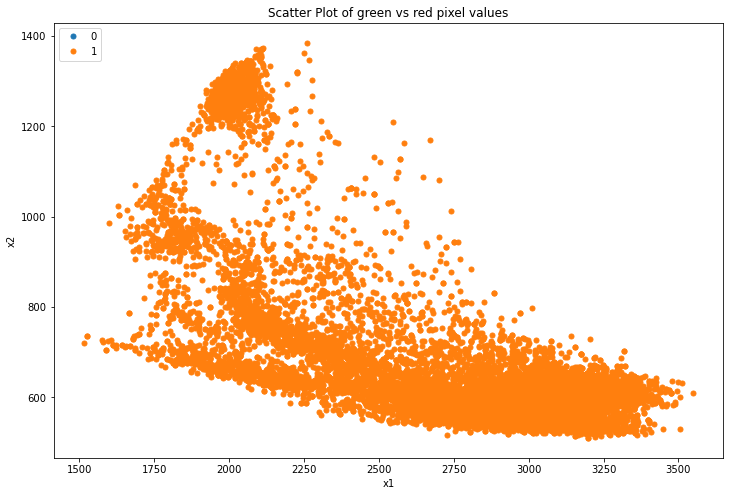

[1. 1. 1. ... 1. 1. 1.]
Accuracy =  0.8927245438028281


In [74]:
hidden_units = 512
iterations = 1000
batch_size = 16
learning_rate = 0.1
W, c, w, b = MLP(hidden_units, iterations, batch_size, learning_rate)
validate(XX, yy, W, c, w, b)

C:\Users\hssid\anaconda3\envs\gis3.6\lib\site-packages\ipykernel_launcher.py:7: RuntimeWarning: overflow encountered in exp
  import sys
C:\Users\hssid\anaconda3\envs\gis3.6\lib\site-packages\ipykernel_launcher.py:12: RuntimeWarning: overflow encountered in exp
  if sys.path[0] == '':


Loss per sample =  0.39295871400957433


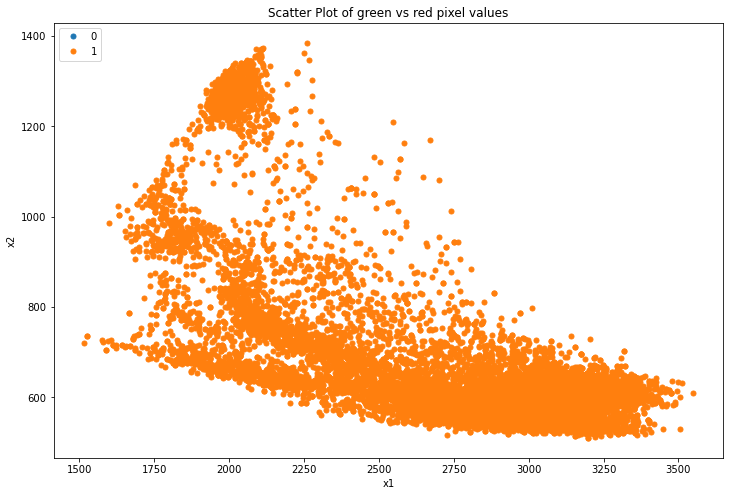

[1. 1. 1. ... 1. 1. 1.]
Accuracy =  0.8927245438028281


In [71]:
hidden_units = 16
iterations = 1000
batch_size = 16
learning_rate = 0.5
W, c, w, b = MLP(hidden_units, iterations, batch_size, learning_rate)
validate(XX, yy, W, c, w, b)

C:\Users\hssid\anaconda3\envs\gis3.6\lib\site-packages\ipykernel_launcher.py:12: RuntimeWarning: overflow encountered in exp
  if sys.path[0] == '':
C:\Users\hssid\anaconda3\envs\gis3.6\lib\site-packages\ipykernel_launcher.py:7: RuntimeWarning: overflow encountered in exp
  import sys


Loss per sample =  0.3927460043587996


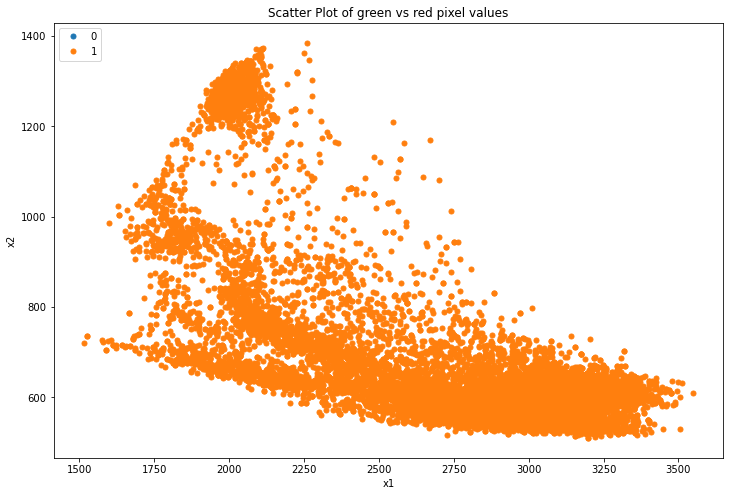

[1. 1. 1. ... 1. 1. 1.]
Accuracy =  0.8927245438028281


In [69]:
hidden_units = 4800
iterations = 1000
batch_size = 64
learning_rate = 0.05
W, c, w, b = MLP(hidden_units, iterations, batch_size, learning_rate)
validate(XX, yy, W, c, w, b)

In [72]:
print("Pixels with vegetation: ",veg_test.shape[0])
print("Pixels without vegetation: ",non_veg_test.shape[0])
print("If you predicted everything as containing vegetation, what would the accuracy be?")
print(veg_test.shape[0]/(veg_test.shape[0]+non_veg_test.shape[0]))

Pixels with vegetation:  11301
Pixels without vegetation:  1358
If you predicted everything as containing vegetation, what would the accuracy be?
0.8927245438028281


# Discussion
#### I've experimented with different learning rates, batch sizes and hidden units but can't get the solution to converge. The model ends up predicting everything as vegetation and thus returns a high accuracy rate!